# Generic Finsler Metrics, Beyond Randers

Randers metrics (shifted ellipses) are one family of Finsler geometry. Since every HAM geometric object is auto-differentiated from the scalar $F(x,v)$, the solver does not depend on where $F$ comes from. Any $F$ that is positively 1-homogeneous and strongly convex in $v$ defines a valid Finsler metric, and its unit balls — the *indicatrices* — can be arbitrary convex shapes. Here we build such metrics and relax geodesics through them.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field, the Finsler cost
$F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are then obtained by
automatic differentiation of $F$ with `jax.grad` / `jax.hessian`, rather than by hand-deriving
Christoffel symbols. The notebooks in this suite share a small plotting style (`ham.vis.style`) so the
figures stay consistent and readable.

## 1. The contract

The AVBD solver touches only `metric.energy` and `manifold.log_map`. To define a new geometry we
subclass `FinslerMetric` and supply `metric_fn`, subject to two conditions:

1. **1-homogeneity:** $F(x,\lambda v) = \lambda F(x, v)$ for $\lambda > 0$, so path length is
   reparameterization-invariant.
2. **Strong convexity** of $F$ in $v$, so the fundamental tensor $g_{ij}=\partial^2_{v}(\tfrac12 F^2)$ is
   positive-definite.

A convenient family that satisfies both is the **anisotropic superellipse gauge**
$$ F(x,v) = \Big( \, |e_1(x)\cdot v / a|^{\,p} + |e_2(x)\cdot v / b|^{\,p} \, \Big)^{1/p}, \qquad p \ge 1, $$
whose frame $(e_1,e_2)$, scales $(a,b)$ and exponent $p$ may depend on position. (A fully general
learnable convex gauge could wrap an Input-Convex Neural Network over $v$ here; the superellipse is a
transparent instance.)

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from ham.geometry import FinslerMetric, EuclideanSpace
from ham.solvers import AVBDSolver
from ham.utils.math import GRAD_EPS
from ham.vis.style import use_ham_style, PALETTE

use_ham_style()
jax.config.update("jax_enable_x64", False)
key = jax.random.PRNGKey(0)
flat = EuclideanSpace(2)


class Superellipse(FinslerMetric):
    """Anisotropic superellipse metric with a (possibly rotating) grain."""
    a: float = 1.0
    b: float = 1.0
    p: float = 4.0
    omega: float = 0.0

    def metric_fn(self, x, v):
        ang = self.omega * x[0]
        c, s = jnp.cos(ang), jnp.sin(ang)
        e1 = jnp.array([c, s])
        e2 = jnp.array([-s, c])
        p1 = jnp.dot(e1, v) / self.a
        p2 = jnp.dot(e2, v) / self.b
        F = (jnp.abs(p1) ** self.p + jnp.abs(p2) ** self.p) ** (1.0 / self.p)
        return jnp.where(jnp.sum(v ** 2) < GRAD_EPS, 0.0, F)

## 2. A gallery of indicatrices

The indicatrix at a point is the unit ball $\{v : F(x,v)=1\}$ — the velocities reachable in unit time.
A Riemannian metric only gives ellipses; Finsler geometry allows diamonds, rounded squares, and squished
variants by varying $(a,b)$ and the exponent $p$.

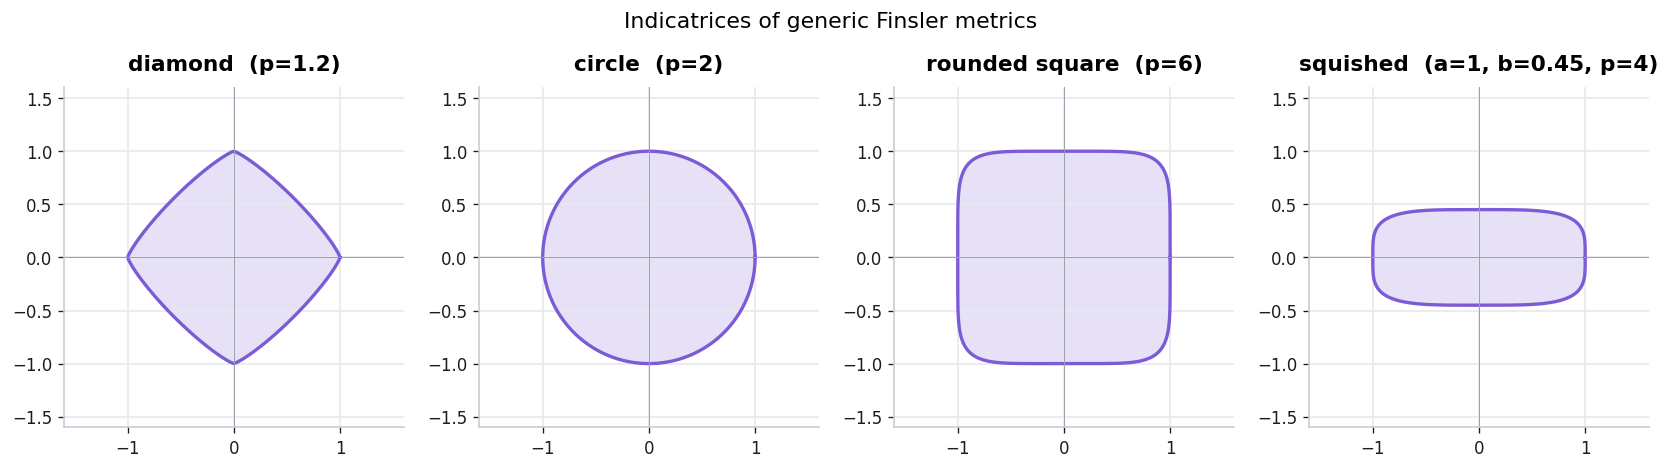

In [2]:
def indicatrix(metric, x, n=240):
    ths = np.linspace(0, 2 * np.pi, n)
    dirs = np.stack([np.cos(ths), np.sin(ths)], axis=1)
    F = np.array([float(metric.metric_fn(jnp.asarray(x), jnp.asarray(d))) for d in dirs])
    return dirs / F[:, None]


gallery = [
    ("diamond  (p=1.2)", Superellipse(manifold=flat, a=1.0, b=1.0, p=1.2)),
    ("circle  (p=2)", Superellipse(manifold=flat, a=1.0, b=1.0, p=2.0)),
    ("rounded square  (p=6)", Superellipse(manifold=flat, a=1.0, b=1.0, p=6.0)),
    ("squished  (a=1, b=0.45, p=4)", Superellipse(manifold=flat, a=1.0, b=0.45, p=4.0)),
]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (name, m) in zip(axes, gallery):
    pts = indicatrix(m, np.zeros(2))
    ax.fill(pts[:, 0], pts[:, 1], color=PALETTE["violet"], alpha=0.18)
    ax.plot(pts[:, 0], pts[:, 1], color=PALETTE["violet"], lw=2)
    ax.set_title(name); ax.set_aspect("equal")
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.axhline(0, color=PALETTE["muted"], lw=0.6); ax.axvline(0, color=PALETTE["muted"], lw=0.6)
fig.suptitle("Indicatrices of generic Finsler metrics", y=1.02)
plt.tight_layout(); plt.show()

## 3. Constant grain: straight geodesics, anisotropic cost

A position-independent metric has straight-line geodesics (the Euler–Lagrange equations have no
$x$-dependence), but travel cost is direction-dependent. With the cheap axis horizontal ($a \gg b$),
horizontal travel costs less even though every shortest path is straight. The indicatrix shows the price
of each heading.

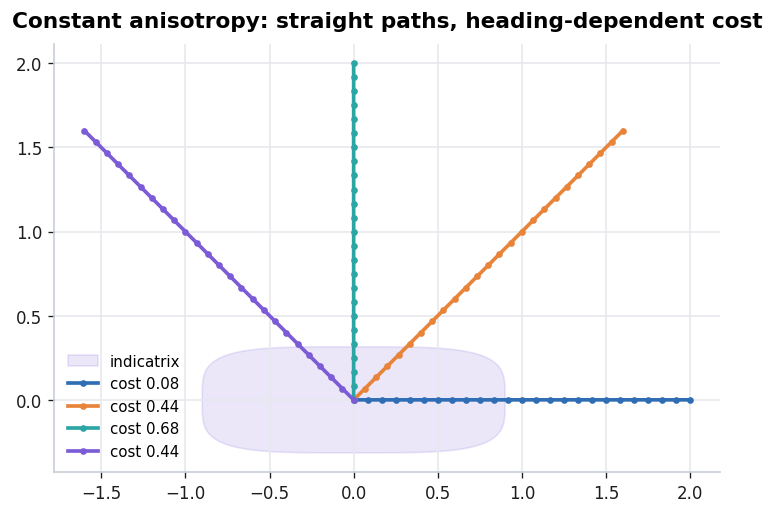

In [3]:
m_const = Superellipse(manifold=flat, a=1.0, b=0.35, p=4.0, omega=0.0)
sol = AVBDSolver(step_size=0.02, iterations=300)
ends = [(2.0, 0.0), (1.6, 1.6), (0.0, 2.0), (-1.6, 1.6)]

fig, ax = plt.subplots(figsize=(6.2, 6.2))
ind = indicatrix(m_const, np.zeros(2))
ax.fill(0.9 * ind[:, 0], 0.9 * ind[:, 1], color=PALETTE["violet"], alpha=0.15, label="indicatrix")
for (ex, ey) in ends:
    tr = sol.solve(m_const, jnp.array([0.0, 0.0]), jnp.array([ex, ey]), n_steps=24, key=key)
    xs = np.array(tr.xs)
    ax.plot(xs[:, 0], xs[:, 1], "-o", ms=3, label=f"cost {float(tr.energy):.2f}")
ax.set_aspect("equal"); ax.legend(fontsize=9)
ax.set_title("Constant anisotropy: straight paths, heading-dependent cost")
plt.tight_layout(); plt.show()

## 4. Position-dependent grain: curved geodesics in flat space

Letting the anisotropy frame rotate with position ($\omega \ne 0$) — like the grain of wood — makes the
cheapest path bend, even though the domain is flat $\mathbb{R}^2$. AVBD finds it with the same call.

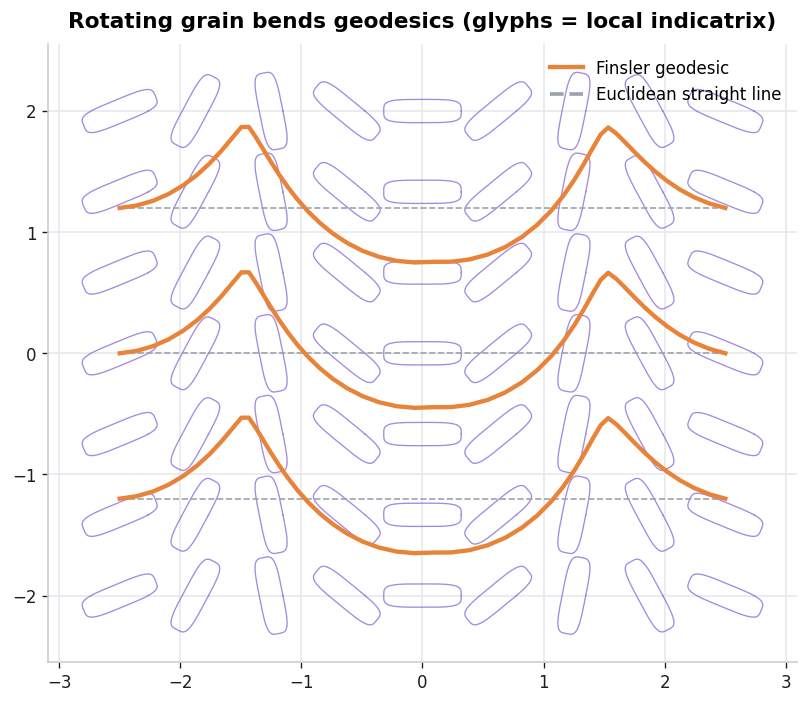

In [4]:
m_grain = Superellipse(manifold=flat, a=1.0, b=0.30, p=4.0, omega=1.1)

fig, ax = plt.subplots(figsize=(8.5, 6))
for gx in np.linspace(-2.5, 2.5, 9):
    for gy in np.linspace(-2.0, 2.0, 7):
        pts = indicatrix(m_grain, np.array([gx, gy]))
        ax.plot(gx + 0.32 * pts[:, 0], gy + 0.32 * pts[:, 1], color=PALETTE["violet"],
                lw=0.8, alpha=0.7)

sol = AVBDSolver(step_size=0.02, iterations=500)
for y0 in (-1.2, 0.0, 1.2):
    tr = sol.solve(m_grain, jnp.array([-2.5, y0]), jnp.array([2.5, y0]), n_steps=48, key=key)
    xs = np.array(tr.xs)
    straight = np.linspace([-2.5, y0], [2.5, y0], 48)
    ax.plot(straight[:, 0], straight[:, 1], color=PALETTE["muted"], ls="--", lw=1)
    ax.plot(xs[:, 0], xs[:, 1], color=PALETTE["accent"], lw=2.6)
ax.plot([], [], color=PALETTE["accent"], lw=2.6, label="Finsler geodesic")
ax.plot([], [], color=PALETTE["muted"], ls="--", label="Euclidean straight line")
ax.set_aspect("equal"); ax.legend()
ax.set_title("Rotating grain bends geodesics (glyphs = local indicatrix)")
plt.tight_layout(); plt.show()

## 5. Checking the contract

Two numerical checks confirm the metric is well-formed: 1-homogeneity to machine precision, and a
positive-definite fundamental tensor for every reference direction.

In [5]:
m = m_grain
x = jnp.array([0.4, -0.3])
v = jnp.array([0.3, 0.7])
print(f"1-homogeneity  F(2v)/F(v) = {float(m.metric_fn(x, 2 * v) / m.metric_fn(x, v)):.6f}   (target 2)")

g_fn = jax.hessian(m.energy, argnums=1)
min_eig = [float(jnp.linalg.eigvalsh(0.5 * (g_fn(x, jnp.array([np.cos(t), np.sin(t)])) +
                                            g_fn(x, jnp.array([np.cos(t), np.sin(t)])).T))[0])
           for t in np.linspace(0, 2 * np.pi, 36, endpoint=False)]
print(f"fundamental tensor min eigenvalue over all directions: {min(min_eig):.4f}  (>0 means convex)")
print("=> valid, strongly-convex Finsler metric." if min(min_eig) > 0 else "=> NOT convex")

1-homogeneity  F(2v)/F(v) = 2.000000   (target 2)


fundamental tensor min eigenvalue over all directions: 0.0019  (>0 means convex)
=> valid, strongly-convex Finsler metric.


## 6. Notes

* A new geometry is a single `metric_fn`; convex and 1-homogeneous is the whole contract, with no
  hand-derived connection.
* Indicatrices are the right mental model: Riemannian metrics give ellipses, Finsler metrics encode
  arbitrary directional preferences.
* Position-dependent anisotropy curves geodesics in flat space, and because the stack is differentiable
  these metrics are learnable end-to-end as in [`demo_learned_wind`](demo_learned_wind.ipynb), with a
  richer parameterization (or an ICNN).